In [3]:
import pandas as pd
import numpy as np

def read_nexus_csv(filepath):
    """
    reads nexus csv file and imports IMU, Force and Marker Data
    returns dict with Data in DF (float) and Sampling Frequencies (int)
    looks like this:
            'df_imu': regular df
            'fs_imu': int
            'df_force': regular df
            'fs_force': fs_force,
            'df_marker': df_marker,
            'fs_marker': fs_marker
    :param filepath:
    :return following dict:
            'df_imu': regular df
            'fs_imu': int
            'df_force': regular df
            'fs_force': int,
            'df_marker': Multiindex DF (1st level: Marker names, 2nd level ['x', 'y', 'z']),
            'fs_marker': int
    """
    # read file in 1 columns with strings
    df = pd.read_csv(filepath, sep=';', header=None)

    # get indices of Device Data
    idx_imu = df[df[0] == 'Devices'].index[0]
    idx_force = df[df[0] == 'Devices'].index[1]
    idx_marker = df[df[0] == 'Trajectories'].index[0]

    # slice string df
    df_imu = df[idx_imu:idx_force]
    df_force = df[idx_force:idx_marker]
    df_marker = df[idx_marker:]

    # get sampling rates in Hz
    fs_imu = int(df_imu.iloc[1])
    fs_force = int(df_force.iloc[1])
    fs_marker = int(df_marker.iloc[1])

    # reshape Device Data and store in DF
    df_imu = df_reshape_imu(df_imu)
    df_force = df_reshape_force(df_force)
    df_marker = df_reshape_marker(df_marker)
    # divide by 1000 to convert acc data from mm/s² to m/s²
    df_imu.iloc[:, :len(df_imu.columns) // 2] = df_imu.iloc[:, :len(df_imu.columns) // 2] / 1000

    # save in dict
    nexus_dict = {
        'df_imu': df_imu,
        'fs_imu': fs_imu,
        'df_force': df_force,
        'fs_force': fs_force,
        'df_marker': df_marker,
        'fs_marker': fs_marker
    }

    return nexus_dict

def df_reshape_imu(df):
    cols = df.iloc[3].values[0].split(',')[2:]
    df = df[0].str.split(',', expand=True).iloc[5:, 2:-1]
    df.columns = cols
    df.reset_index(drop=True, inplace=True)
    return df.astype('float64')

def df_reshape_force(df):
    cols = df.iloc[3].values[0].split(',')[6:]
    df = df[0].str.split(',', expand=True).iloc[5:, 6:-1]
    df.columns = cols
    df.reset_index(drop=True, inplace=True)
    return df.astype('float64')

def df_reshape_marker(df_in):
    markers = [name[4:] for name in df_in.iloc[2].values[0].replace(',,', '').split(',')[:-1]]
    cols = [np.repeat(markers, 3), np.tile(['x', 'y', 'z'], len(markers))]
    df_out = df_in[0].str.split(',',expand=True).iloc[5:,2:-1]
    df_out.columns=cols
    df_out.reset_index(drop=True, inplace=True)
    return df_out.astype('float64')

In [9]:
filepath = r'D:\Salzburg\Study1\P01\P01_treadmill\20221205_P01_UB_8.csv'
treadmill = read_nexus_csv(filepath)

In [17]:
i = 0

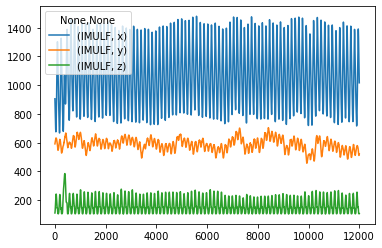

In [76]:
mark = treadmill['df_marker'].columns[i:i+3]
treadmill['df_marker'][mark].plot()
i+=3

In [79]:
treadmill.keys()

dict_keys(['df_imu', 'fs_imu', 'df_force', 'fs_force', 'df_marker', 'fs_marker'])